# Econ 390 - Lecture 22: Categorical Variables
Today we will be going over category type variables and use them to do comparisons across groups. You can find readings in [McKinney](https://wesmckinney.com/book/data-cleaning#pandas-categorical) and [Turrell](https://aeturrell.github.io/coding-for-economists/data-categorical.html#categorical-data)

![image](https://m-mcmain.github.io/files/Econ390SP26/announcements/CROWE_Neal_4-16-26.jpg)

## Course Evaluations Open Tomorrow
You should be getting an email tomorrow about Course Evaluations! I would **really** appreciate if you could take 5-10 minutes filling it out honestly and constructively so I can improve the course for the next generation of *Intro to Coding for Economists* Students!

You should be able to find the survey starting tomorrow morning [here](https://heliocampusac.wisc.edu/index.cfm/page/AefisDashboard.home?action=openSurveyForm) or you can keep an eye out for emails from `learningassessment@provost.wisc.edu`! The survey will be open until 11:59pm on Friday May 1st.

In [1]:
import pandas as pd
auto = pd.read_csv("https://www.statlearning.com/s/Auto.csv")
auto

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
392,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
393,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
394,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
395,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


## Categorical Data

In [2]:
# Check out origin
auto["origin"].value_counts()

origin
1    248
3     79
2     70
Name: count, dtype: int64

In [8]:
# Create a new variable
auto["foreign"] = (auto["origin"] != 1).astype("int")
auto

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name,foreign
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu,0
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320,0
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite,0
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst,0
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino,0
...,...,...,...,...,...,...,...,...,...,...
392,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl,0
393,44.0,4,97.0,52,2130,24.6,82,2,vw pickup,1
394,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage,0
395,28.0,4,120.0,79,2625,18.6,82,1,ford ranger,0


In [9]:
# pd.Categorical
pd.Categorical.from_codes(auto["foreign"], ["Domestic", "Foreign"])

['Domestic', 'Domestic', 'Domestic', 'Domestic', 'Domestic', ..., 'Domestic', 'Foreign', 'Domestic', 'Domestic', 'Domestic']
Length: 397
Categories (2, object): ['Domestic', 'Foreign']

In [10]:
# Convert the variable
auto["foreign"] = pd.Categorical.from_codes(auto["foreign"], ["Domestic", "Foreign"])

In [16]:
# cat method
auto["foreign"].cat

In [17]:
# Categories
auto["foreign"].cat.categories

Index(['Domestic', 'Foreign'], dtype='object')

In [18]:
# Codes
auto["foreign"].cat.codes

0      0
1      0
2      0
3      0
4      0
      ..
392    0
393    1
394    0
395    0
396    0
Length: 397, dtype: int8

In [21]:
# Alternative Method
category_mapping = {1:"Domestic",2:"Foreign",3:"Foreign"}
auto["foreign_alt"] = auto["origin"].map(category_mapping).astype("category")
auto

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name,foreign,foreign_alt
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu,Domestic,Domestic
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320,Domestic,Domestic
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite,Domestic,Domestic
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst,Domestic,Domestic
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino,Domestic,Domestic
...,...,...,...,...,...,...,...,...,...,...,...
392,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl,Domestic,Domestic
393,44.0,4,97.0,52,2130,24.6,82,2,vw pickup,Foreign,Foreign
394,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage,Domestic,Domestic
395,28.0,4,120.0,79,2625,18.6,82,1,ford ranger,Domestic,Domestic


In [22]:
# Aggregation
auto.groupby("foreign").mean(numeric_only=True)

C:\Users\micha\AppData\Local\Temp\ipykernel_10968\2512806637.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  auto.groupby("foreign").mean(numeric_only=True)


,mpg,cylinders,displacement,weight,acceleration,year,origin
foreign,,,,,,,
Domestic,20.071774,6.258065,246.284274,3363.250000,15.011694,75.584677,1.000000
Foreign,29.248322,4.127517,105.731544,2316.161074,16.461074,76.677852,2.530201


## Regression Models with Categories

In [23]:
# Import seaborn and smf
import seaborn as sns
import statsmodels.formula.api as smf

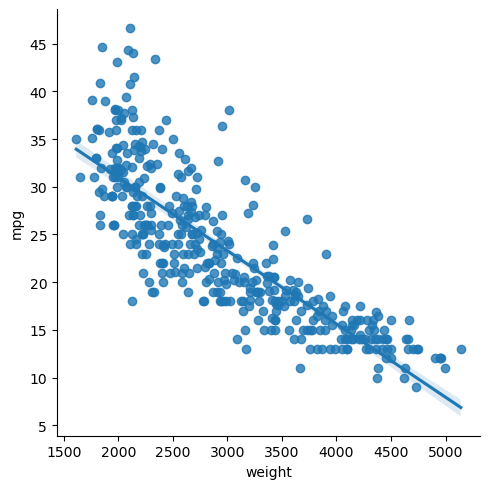

In [25]:
# lmplot with weight and mpg
sns.lmplot(x="weight",y="mpg",data=auto);

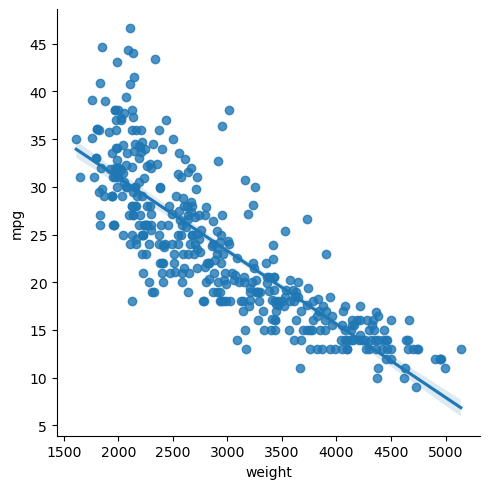

In [28]:
# lmplot with customization
sns.lmplot(x="weight",y="mpg",data=auto);

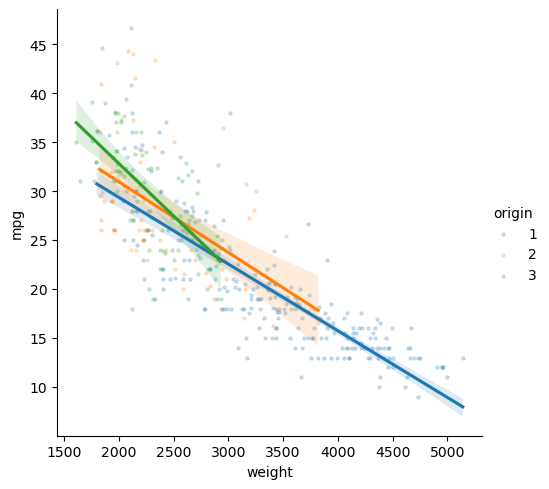

In [42]:
# lmplot with customization
sns.lmplot(x="weight",y="mpg", hue="origin", data=auto, scatter_kws={"alpha":0.2,"s":5});

In [32]:
# model using smf
model1 = smf.ols("mpg ~ weight", data=auto).fit(cov_type="HC1")
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.692
Model:                            OLS   Adj. R-squared:                  0.691
Method:                 Least Squares   F-statistic:                     1072.
Date:                Thu, 16 Apr 2026   Prob (F-statistic):          1.27e-114
Time:                        15:01:33   Log-Likelihood:                -1146.0
No. Observations:                 397   AIC:                             2296.
Df Residuals:                     395   BIC:                             2304.
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     46.3174      0.823     56.269      0.0

In [35]:
# Comparing across models
from statsmodels.iolib.summary2 import summary_col
model1 = smf.ols("mpg ~ weight", data=auto[auto["foreign"]=="Domestic"]).fit(cov_type="HC1")
model2 = smf.ols("mpg ~ weight", data=auto[auto["foreign"]=="Foreign"]).fit(cov_type="HC1")
print(summary_col([model1,model2],stars=True,float_format="%0.3f",
                  model_names=["Domestic","Foreign"]))


                Domestic  Foreign 
----------------------------------
Intercept      42.985*** 49.184***
               (1.121)   (2.342)  
weight         -0.007*** -0.009***
               (0.000)   (0.001)  
R-squared      0.715     0.309    
R-squared Adj. 0.714     0.304    
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


In [39]:
# Categorical in the Model
model3 = smf.ols("mpg ~ weight + foreign + weight:foreign", data=auto).fit(cov_type="HC1")
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.703
Model:                            OLS   Adj. R-squared:                  0.700
Method:                 Least Squares   F-statistic:                     399.5
Date:                Thu, 16 Apr 2026   Prob (F-statistic):          5.95e-119
Time:                        15:18:45   Log-Likelihood:                -1139.0
No. Observations:                 397   AIC:                             2286.
Df Residuals:                     393   BIC:                             2302.
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [41]:
# Alternate way of typing it
model3 = smf.ols("mpg ~ weight*origin", data=auto).fit(cov_type="HC1")
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.705
Model:                            OLS   Adj. R-squared:                  0.703
Method:                 Least Squares   F-statistic:                     397.2
Date:                Thu, 16 Apr 2026   Prob (F-statistic):          1.41e-118
Time:                        15:20:17   Log-Likelihood:                -1137.4
No. Observations:                 397   AIC:                             2283.
Df Residuals:                     393   BIC:                             2299.
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        38.7749      2.227     17.415

## Binning Data
We did a little bit of this all the way back in [Lecture 12](https://m-mcmain.github.io/pages/Econ_390_SP26_L12/)!

In [44]:
# Distribution of years
auto["year"].value_counts().sort_index()

year
70    29
71    28
72    28
73    40
74    27
75    30
76    34
77    28
78    36
79    29
80    29
81    29
82    30
Name: count, dtype: int64

In [45]:
# Means across years
auto[["year","mpg"]].groupby("year").mean()

,mpg
year,
70,17.689655
71,21.250000
72,18.714286
73,17.100000
74,22.703704
75,20.266667
76,21.573529
77,23.375000
78,24.061111


In [47]:
# Using cut
auto["year_bin"] = pd.cut(auto["year"], bins = [69, 73, 77, 82], right=True, 
                          labels = ["Early 70s", "Mid 70s", "Late 70s-Early 80s"])
auto

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name,foreign,foreign_alt,year_bin
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu,Domestic,Domestic,Early 70s
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320,Domestic,Domestic,Early 70s
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite,Domestic,Domestic,Early 70s
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst,Domestic,Domestic,Early 70s
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino,Domestic,Domestic,Early 70s
...,...,...,...,...,...,...,...,...,...,...,...,...
392,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl,Domestic,Domestic,Late 70s-Early 80s
393,44.0,4,97.0,52,2130,24.6,82,2,vw pickup,Foreign,Foreign,Late 70s-Early 80s
394,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage,Domestic,Domestic,Late 70s-Early 80s
395,28.0,4,120.0,79,2625,18.6,82,1,ford ranger,Domestic,Domestic,Late 70s-Early 80s


In [48]:
# groupby again
auto[["year_bin","mpg"]].groupby("year_bin").mean()

C:\Users\micha\AppData\Local\Temp\ipykernel_10968\3944153947.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  auto[["year_bin","mpg"]].groupby("year_bin").mean()


,mpg
year_bin,
Early 70s,18.528000
Mid 70s,21.924370
Late 70s-Early 80s,28.828758


In [50]:
# ols on bins
model4 = smf.ols("mpg ~ year_bin",data=auto).fit(cov_type="HC1")
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.319
Model:                            OLS   Adj. R-squared:                  0.315
Method:                 Least Squares   F-statistic:                     87.69
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           3.15e-32
Time:                        15:32:52   Log-Likelihood:                -1303.4
No. Observations:                 397   AIC:                             2613.
Df Residuals:                     394   BIC:                             2625.
Df Model:                           2                                         
Covariance Type:                  HC1                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

In [55]:
# qcut
auto["year_quantile"] = pd.qcut(auto["year"], 2, labels=["70-76", "77-82"])
auto

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name,foreign,foreign_alt,year_bin,year_quantile
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu,Domestic,Domestic,Early 70s,70-76
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320,Domestic,Domestic,Early 70s,70-76
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite,Domestic,Domestic,Early 70s,70-76
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst,Domestic,Domestic,Early 70s,70-76
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino,Domestic,Domestic,Early 70s,70-76
...,...,...,...,...,...,...,...,...,...,...,...,...,...
392,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl,Domestic,Domestic,Late 70s-Early 80s,77-82
393,44.0,4,97.0,52,2130,24.6,82,2,vw pickup,Foreign,Foreign,Late 70s-Early 80s,77-82
394,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage,Domestic,Domestic,Late 70s-Early 80s,77-82
395,28.0,4,120.0,79,2625,18.6,82,1,ford ranger,Domestic,Domestic,Late 70s-Early 80s,77-82


In [56]:
# groupby again, qcut
auto[["year_quantile","mpg"]].groupby("year_quantile").mean()

C:\Users\micha\AppData\Local\Temp\ipykernel_10968\1716184374.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  auto[["year_quantile","mpg"]].groupby("year_quantile").mean()


,mpg
year_quantile,
70-76,19.770833
77-82,27.985083


In [58]:
# ols on quantiles
model5 = smf.ols("mpg ~ year_quantile",data=auto).fit(cov_type="HC1")
print(model5.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.274
Model:                            OLS   Adj. R-squared:                  0.272
Method:                 Least Squares   F-statistic:                     142.8
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           2.62e-28
Time:                        15:39:07   Log-Likelihood:                -1316.1
No. Observations:                 397   AIC:                             2636.
Df Residuals:                     395   BIC:                             2644.
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 19

## Practice Binning
1. Create a variable called `horsepower_tercile` that splits the `horsepower` variable into thirds, label them appropriately. *Hint: What type is `horsepower`? Sort by index to see the range.*
2. Create a variable called `horsepower_bins` that splits `horsepower` into three equally sized bins
3. Are these different?

In [62]:
# Question marks show up... Must be NA?
auto["horsepower"].sort_values()

133    100
98     100
256    100
107    100
334    100
      ... 
336      ?
126      ?
354      ?
32       ?
330      ?
Name: horsepower, Length: 397, dtype: object

In [64]:
# Treated as a string
type(auto["horsepower"][1])

str

In [65]:
# Drop the question marks and convert to int
auto = auto.drop(auto[auto["horsepower"] == "?"].index)
auto["horsepower"] = auto["horsepower"].astype(int)
auto

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name,foreign,foreign_alt,year_bin,year_quantile
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu,Domestic,Domestic,Early 70s,70-76
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320,Domestic,Domestic,Early 70s,70-76
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite,Domestic,Domestic,Early 70s,70-76
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst,Domestic,Domestic,Early 70s,70-76
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino,Domestic,Domestic,Early 70s,70-76
...,...,...,...,...,...,...,...,...,...,...,...,...,...
392,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl,Domestic,Domestic,Late 70s-Early 80s,77-82
393,44.0,4,97.0,52,2130,24.6,82,2,vw pickup,Foreign,Foreign,Late 70s-Early 80s,77-82
394,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage,Domestic,Domestic,Late 70s-Early 80s,77-82
395,28.0,4,120.0,79,2625,18.6,82,1,ford ranger,Domestic,Domestic,Late 70s-Early 80s,77-82


In [66]:
# 1.
auto["horsepower_tercile"] = pd.qcut(auto["horsepower"],3, labels=["lower","mid", "upper"])
# 2.
auto["horsepower_bins"] = pd.cut(auto["horsepower"], 3, labels=["lower","mid", "upper"])
auto
# 3.
# They are different! quantile is based on the data itself and should be approximately 1/3 in each category
# cut makes the bin sizes the same, so it just splits the min to max into thirds and however much data is in each bin doesn't matter
print(auto["horsepower_tercile"].value_counts())
print(auto["horsepower_bins"].value_counts())

horsepower_tercile
mid      144
lower    132
upper    116
Name: count, dtype: int64
horsepower_bins
lower    257
mid      103
upper     32
Name: count, dtype: int64
